# Vocabulary

Lexical diversity metrics seek to measure the richness of vocabulary used in a text. The Zipfian distribution of word frequencies makes this harder to quantify than it might seem at first glance. Vocabulary size is highly dependent on text length. The further a text runs the more its words repeat, and a metric that looks like a description of its vocabulary often turns out to be a description of its size. Each measure below is a partial solution to that problem.

1. **Type-token ratio** -- `ttr`, over a whole text and over a fixed window, which is where the length problem shows itself.
2. **Length-controlled measures** -- `msttr` and `mtld`, and how far the three of them agree.
3. **One word class at a time** -- the same measures over the nouns and the verbs alone, and what a shorter, more varied sequence does to them.
4. **Vocabulary growth curves** -- `vocabulary_growth`, which displays the dependence on length instead of correcting for it.
5. **The frequency spectrum** -- `frequency_spectrum`, the distribution all of these summarize.

The first three sections use the Brown corpus. For the remainder, we need longer text samples and use a selection of books.  For reference about the functions called here, see: [Lexical metrics API](../../lexical/).

**References**

- Baayen, R. H. 2001. *Word Frequency Distributions.* Kluwer Academic Publishers.
- Johnson, W. 1944. Studies in language behavior: A program of research. *Psychological Monographs* 56(2): 1-15.
- McCarthy, P. M. & Jarvis, S. 2010. MTLD, vocd-D, and HD-D: A validation study of sophisticated approaches to lexical diversity assessment. *Behavior Research Methods* 42(2): 381-392.
- Tweedie, F. J. & Baayen, R. H. 1998. How variable may a constant be? Measures of lexical richness in perspective. *Computers and the Humanities* 32(5): 323-352.

In [1]:
import polars as pl
import polars_corpus as plc
import polars.selectors as cs
import matplotlib.pyplot as plt
import seaborn as sns

pl.Config.set_float_precision(3)
pl.Config.set_tbl_rows(15)

polars.config.Config

## The corpus

These examples use the Brown corpus: 500 texts of about 2,000 words each, sampled from American English printed in 1961 and sorted into fifteen categories. 

| column         | contents |
|----------------| --- |
| `token`        | the word form as it appears in the text |
| `tag`          | part-of-speech tag (Brown tagset) |
| `sentence_tag` | `B` on the first token of a sentence, `I` elsewhere |
| `file_id`      | the text the token belongs to |
| `category`     | the text's genre |

We normalize the text in the same way we did in [Word frequencies](../frequencies/): `plc.is_letters` keeps the tokens made of letters, apostrophes and hyphens while dropping punctuation and numerals, and `str.to_lowercase` folds *The* in with *the*. Both matter more here than they do for a frequency list, because every measure below counts positions in a sequence rather than rows in a table -- with the punctuation gone, a comma no longer occupies a slot in a segment or a factor. 

In [2]:
brown = (
    pl.scan_parquet("../../data/brown.parquet")
    .filter(plc.is_letters("token"))
    .with_columns(pl.col("token").str.to_lowercase())
    .collect()
)

## Four measures at once

`group_by("file_id")` makes each text a group and `agg` returns one row per text, with `pl.col("category").first()` carrying the genre label through as constant. The measures are all expressions, so they compose with ordinary Polars:

- `plc.ttr("token")` is the type-token ratio $V/N$ over the whole text.
- `plc.ttr(pl.col("token").head(250))` is the same ratio over the first 250 tokens. Nothing special is needed to restrict the window: `ttr` takes an expression, and `head` is an expression.
- `plc.msttr("token", 250)` cuts the text into consecutive 250-token segments, takes each segment's TTR and averages them. The tail left over after the last complete segment is dropped, and any text sample shorter than a single segment comes back null.
- `plc.mtld("token")` reads through the text keeping a running TTR, closes a **factor** each time that ratio falls to 0.720, and reports the mean number of tokens per factor, averaged over a forward and a backward pass. Texts under ten tokens come back null.

`cs.numeric().mean()` then averages all numeric columns in the DataFrame.

In [3]:
msttr = brown.group_by("file_id").agg(
    pl.col("category").first(),
    plc.ttr("token").alias("ttr"),
    plc.ttr(pl.col("token").head(250)).alias("ttr250"),
    plc.msttr("token", 250).alias("msttr"),
    plc.mtld("token").alias("mtld"),
)
msttr.group_by("category").agg(cs.numeric().mean())

category,ttr,ttr250,msttr,mtld
str,f64,f64,f64,f64
"""lore""",0.376,0.607,0.607,95.220
"""learned""",0.323,0.568,0.557,73.701
"""humor""",0.418,0.634,0.632,117.023
"""news""",0.409,0.611,0.613,99.253
"""adventure""",0.370,0.621,0.615,104.932
"""fiction""",0.377,0.606,0.607,97.180
"""reviews""",0.446,0.631,0.645,119.912
"""religion""",0.352,0.565,0.579,79.682
"""editorial""",0.413,0.607,0.617,99.606


The whole-file ratio and the 250-token one disagree about the scale of everything but agree about the ordering. Whole-file TTR averages between 0.311 (`government`) and 0.446 (`reviews`), while the same texts measured over their first 250 tokens average between 0.542 and 0.634. Nothing about the vocabulary changed between those two columns; only the denominator did. What survives the change is the ranking -- `government` and `learned` near the bottom, `reviews` and `humor` near the top, under all four measures. This only happens, though, because the samples all have the same length.

That ranking is what the box plot draws. `m` is the category's mean MTLD, computed as a window function and used only for sorting: seaborn draws categories in the order it finds them in the frame, so sorting the frame is how the axis gets ordered.

Text(0.5, 1.0, 'Brown corpus lexical diversity')

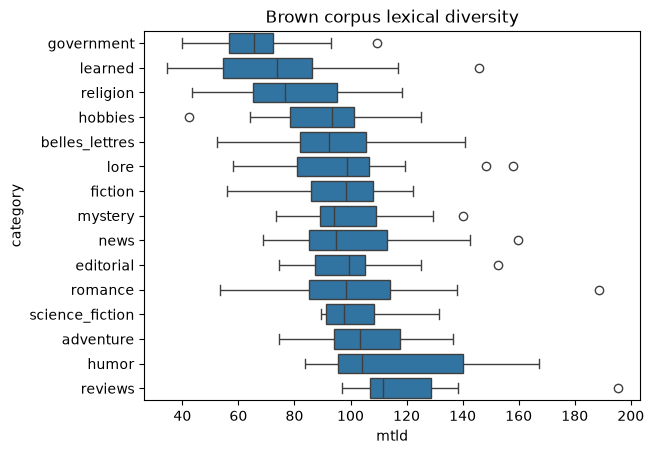

In [4]:
z = msttr.with_columns(m=pl.col("mtld").mean().over("category")).sort(by="m")


sns.boxplot(z, x="mtld", y="category")
plt.title("Brown corpus lexical diversity")

The differences between categories are real but small beside the spread within them. `government` and `learned` sit lowest and `reviews` and `humor` highest, but every box overlaps most of the others and the whiskers overlap almost entirely. Genre influences lexical diversity, but only loosely.

### Do the measures agree?

`msttr` and `ttr250` are both measured at 250 tokens -- the first averaged over the seven or eight complete segments of a Brown text, the second taken from the opening segment alone -- so the scatter below is a picture of how much one 250-token window varies. The relationship is positive but with a lot of noise. This shows the benefit of averaging over multiple segments rather than trusting the first one.

Text(0.5, 1.0, 'Brown corpus lexical diversity')

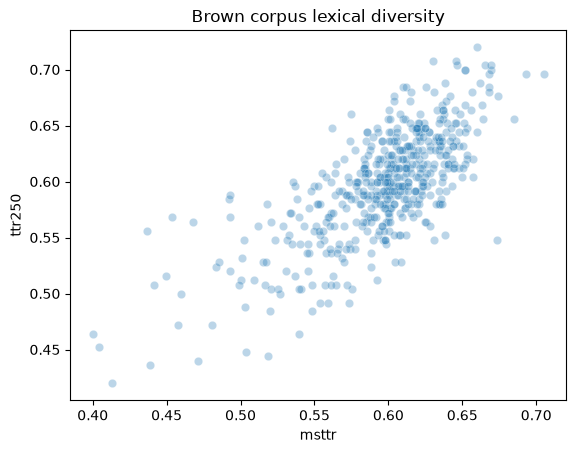

In [5]:
sns.scatterplot(z, x="msttr", y="ttr250", alpha=0.3)
plt.title("Brown corpus lexical diversity")

`mtld` and `msttr` agree far more closely, but along a curve rather than a line. The top of the `msttr` range, from about 0.65 to 0.71, stretches across MTLD values from 140 to nearly 200, while the bottom of the range compresses. The two order the texts almost identically; what differs is the scale, and MTLD's has no upper bound.

Text(0.5, 1.0, 'Brown corpus lexical diversity')

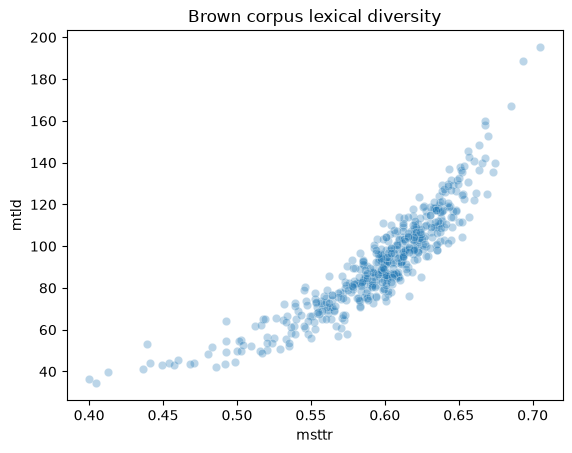

In [6]:
sns.scatterplot(z, x="msttr", y="mtld", alpha=0.3)
plt.title("Brown corpus lexical diversity")

## One word class at a time

Restricting the corpus to a single word class asks a narrower question: not how varied a text is, but how varied its nouns, verbs, etc. are. The filter is a regex on the raw tag, so `^N.*` collects common and proper nouns, plurals, possessives, and the adverbial nouns tagged `NR`.

Note the scale. Whole-text MTLD ran from about 30 to 200; over nouns alone it runs past 1,300. Noun vocabulary is not seven times more diverse than the text that contains it, and we'll take a closer look at this figure in the next section.

Text(0.5, 1.0, 'Brown corpus lexical diversity: Nouns')

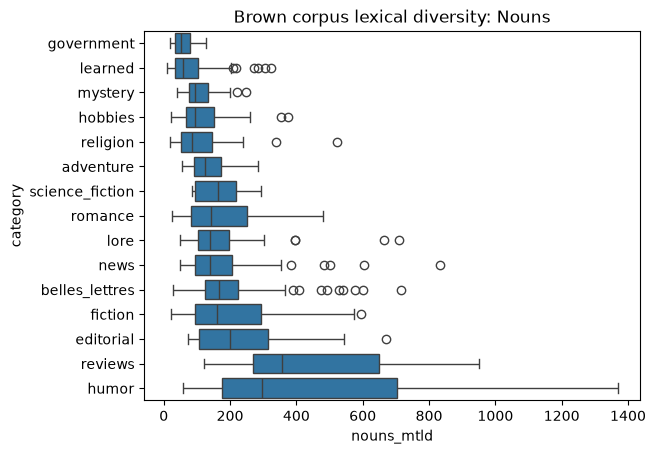

In [7]:
nouns = (
    brown.filter(pl.col("tag").str.contains("^N.*"))
    .group_by("file_id")
    .agg(pl.col("category").first(), plc.mtld("token").alias("nouns_mtld"))
    .with_columns(m=pl.col("nouns_mtld").mean().over("category"))
    .sort(by="m")
)

sns.boxplot(nouns, x="nouns_mtld", y="category")
plt.title("Brown corpus lexical diversity: Nouns")

The same for verbs, with one consequence of the tagset worth naming: Brown gives *be*, *have* and *do* their own tag families (`BE`, `BEZ`, `BED`, and so on through `HV...` and `DO...`) and tags the modals `MD`, none of which begin with `V`. `^V.*` therefore selects the lexical verbs but leaves out the auxiliaries and modals.

Verb sequences are shorter than noun ones, a few hundred tokens in a 2,000-word text, and the boxes are wider still.

Text(0.5, 1.0, 'Brown corpus lexical diversity: Verbs')

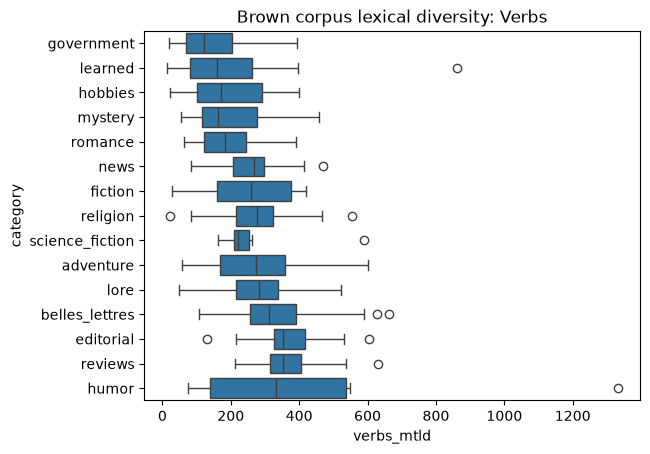

In [8]:
verbs = (
    brown.filter(pl.col("tag").str.contains("^V.*"))
    .group_by("file_id")
    .agg(pl.col("category").first(), plc.mtld("token").alias("verbs_mtld"))
    .with_columns(m=pl.col("verbs_mtld").mean().over("category"))
    .sort(by="m")
)

sns.boxplot(verbs, x="verbs_mtld", y="category")
plt.title("Brown corpus lexical diversity: Verbs")

The join operation puts the three MTLD columns side by side in a single DataFrame. Both `nouns` and `verbs` carry along the `m` column they were sorted by, so the second one arrives as `m_right`; the columns to read in the outputs below are `mtld`, `nouns_mtld` and `verbs_mtld`. Seaborn takes Polars frames directly for most of its plots, but `pairplot` still needs `.to_pandas()`.

The three distributions on the diagonal show us that whole-text MTLD is close to symmetric while the noun and verb measures are heavily right-skewed, with a long thin tail and one text sitting by itself at the far right of every panel it appears in.

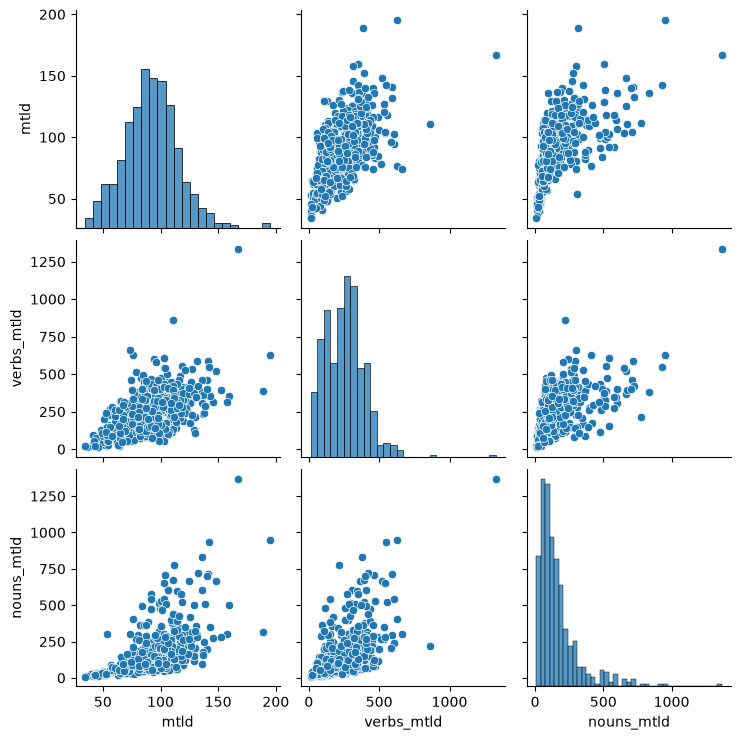

In [9]:
combined = msttr.join(nouns, on=["file_id", "category"]).join(
    verbs, on=["file_id", "category"]
)

sns.pairplot(data=combined.select("mtld", "verbs_mtld", "nouns_mtld").to_pandas())

## A closer look at MTLD

MTLD divides a text into factors and reports tokens per factor, but a factor only closes when the running TTR falls to the threshold. Whatever is left over at the end contributes a fractional factor instead,

$$\text{partial} = \frac{1 - \text{TTR}}{1 - 0.720}$$

If the TTR of the whole sequence never falls to 0.720, that fraction is the entire factor count. It is necessarily less than one, so the score comes out larger than the number of tokens in the sequence -- a number that records only that the text ran out before the measure got started. It describes the length of the text relative to the threshold, not the text.

This isn't an issue for longer texts, but when we filter for one word class we shorten the sequence and raise its TTR at the same time. Here we find the most extreme case:

In [10]:
combined.filter(pl.col("nouns_mtld") > 1000)

file_id,category,ttr,ttr250,msttr,mtld,nouns_mtld,m,verbs_mtld,m_right
str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""cr09""","""humor""",0.509,0.656,0.685,167.263,1368.646,471.314,1331.280,408.544


`cr09` scores 1368.646 on nouns and 1331.280 on verbs, out of a text of some 2,000 words: both sequences are in the regime above. Since the corpus is in reading order, the text can be reassembled from the `token` column -- `head(250)` takes the opening, `str.join(" ")` puts the tokens back together, and `.item()` pulls the single string out of the one-row result (though we can't reverse the normalization and the punctuation and the capitals are gone).

In [11]:
(brown.filter(pl.col("file_id") == "cr09")["token"].head(250).str.join(" ")).item()

"dear sirs let me begin by clearing up any possible misconception in your minds wherever you are the collective by which i address you in the title above is neither patronizing nor jocose but an exact industrial term in use among professional thieves it is i am reliably given to understand the technical argot for those who engage in your particular branch of the boost burglars who rob while the tenants are absent in contrast to hot-slough prowlers those who work while the occupants are home since the latter obviously require an audacity you do not possess you may perhaps suppose that i am taunting you as socially inferior far from it i merely draw an etymological distinction hoping that specialists and busy people like you will welcome such precision in a layman above all disabuse yourselves of any thought that i propose to vent moral indignation at your rifling my residence to whimper over the loss of a few objets d'art or to shame you into rectitude my object rather is to alert you t

This appears to be a comic letter addressed to a pair of burglars, which reaches for a different noun in almost every phrase -- *misconception*, *minds*, *title*, *term*, *thieves*, *argot*, *branch*, *burglars*, *tenants*, *prowlers*, *occupants*, *audacity* -- and repeats hardly any of them. Nothing has gone wrong with either the text or the measure. The sequence simply never repeats itself enough for a factor to close.

Filtering on the verb score turns up `cr09` again, and one more text.

In [12]:
combined.filter(pl.col("verbs_mtld") > 800)

file_id,category,ttr,ttr250,msttr,mtld,nouns_mtld,m,verbs_mtld,m_right
str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""cj68""","""learned""",0.429,0.680,0.631,111.055,217.147,79.743,862.470,183.856
"""cr09""","""humor""",0.509,0.656,0.685,167.263,1368.646,471.314,1331.280,408.544


`cj68` is the more instructive of the two, because only half of it degenerates: 862.470 on verbs against 217.147 on nouns, which is high but ordinary. The essay below returns to *hands*, *gesture*, *novel* and *Dickens* throughout while its verbs vary freely, and the two measures split accordingly.

In [13]:
(brown.filter(pl.col("file_id") == "cj68")["token"].head(250).str.join(" ")).item()

"recent criticism of great expectations has tended to emphasize its symbolic and mythic content to show as zabel has said of dickens generally that much of the novel's impact resides in its allegoric insight and moral metaphor miller's excellent chapter on great expectations has lately illustrated how fruitfully that novel can be read from such a perspective in his analysis however he touches upon but fails to explore an idea generally neglected in discussions of the book which i believe is central to its art the importance of human hands as a recurring feature of the narrative this essay seeks to make that exploration dickens was not for nothing the most theatrical of the great victorian writers he knew instinctively that next to voice and face an actor's hands are his most useful possession that in fiction as in the theatre gesture is an indispensable shorthand for individualizing character and dramatizing action and response it is hardly accidental therefore that many of his most vi

## Vocabulary growth

Every measure so far reduces a text to a single number by accounting for, somehow, the text length. A growth curve does the opposite: it plots vocabulary against length directly and leaves the reading to the eye. That needs texts long enough to have a shape, so the corpus changes here to five books from the Gutenberg collection, one file each, running from a collection of children's stories to a novel several times its length.

Putting `.select("token", "file_id")` before the filter means the scan reads two columns and no more, and the `is_in` predicate pushes down into it, so only the five books are ever read from disk.

In [14]:
subset = [
    "austen-emma.txt",
    "chesterton-ball.txt",
    "edgeworth-parents.txt",
    "melville-moby_dick.txt",
    "bryant-stories.txt",
]

books = (
    pl.scan_parquet("../../data/books.parquet")
    .select("token", "file_id")
    .filter(pl.col("file_id").is_in(subset), plc.is_letters("token"))
    .with_columns(pl.col("token").str.to_lowercase())
    .collect()
)

MTLD ranks the five from `bryant-stories.txt` at 55.816 up to `melville-moby_dick.txt` at 105.638, and the bar chart that follows plots the same five numbers. These books differ in length by a factor of several, which is the comparison a raw type-token ratio cannot make: the gap between the `ttr` and `ttr250` columns in the Brown table above is what a whole-text ratio would do to a ranking like this one.

In [15]:
mtld = books.group_by("file_id").agg(plc.mtld("token").alias("mtld")).sort(by="mtld")
mtld

file_id,mtld
str,f64
"""bryant-stories.txt""",55.816
"""edgeworth-parents.txt""",77.037
"""chesterton-ball.txt""",79.959
"""austen-emma.txt""",91.232
"""melville-moby_dick.txt""",105.638


<Axes: xlabel='mtld', ylabel='file_id'>

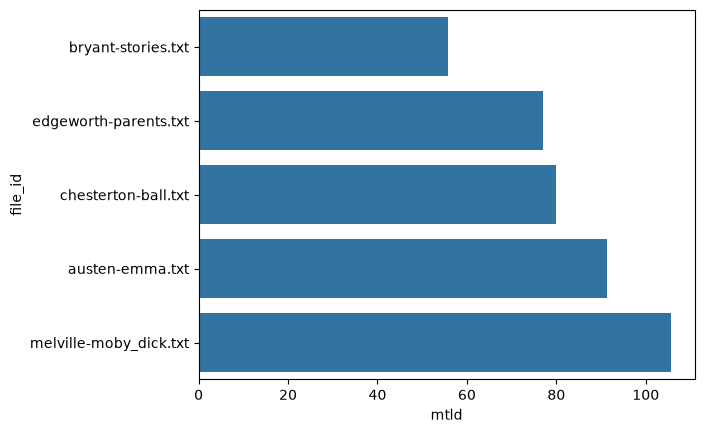

In [16]:
sns.barplot(mtld, y="file_id", x="mtld")

`vocabulary_growth` is the one measure here that returns a column rather than a scalar: one value per token, the number of distinct types seen up to that point, so the last row is the text's type count. Its implementation is plain Polars underneath -- `is_first_distinct().cum_sum()` -- and `with_row_index` supplies the token position to plot it against.

The curve for *Emma* climbs steeply and then bends, but it never flattens. At 160,000 tokens the novel is still introducing words it has not used before, and the total would have been higher had Austen written another chapter. This is the sense in which a text does not have a vocabulary size, only a vocabulary size at a given length.

Text(0.5, 1.0, 'Vocabulary growth curve: Emma')

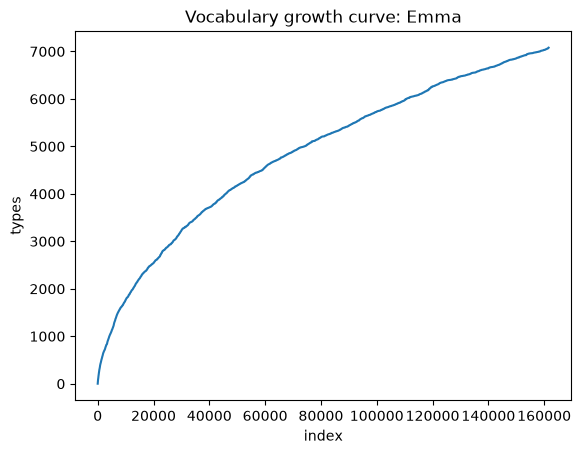

In [17]:
vgc = (
    books.filter(pl.col("file_id") == "austen-emma.txt")
    .with_columns(plc.vocabulary_growth("token").alias("types"))
    .with_row_index()
)

sns.lineplot(vgc, x="index", y="types")
plt.title("Vocabulary growth curve: Emma")

All five at once. `.over("file_id")` computes the running count within each book and writes it back to the rows it came from, and `pl.row_index().over("file_id")` restarts the position count at each book so the curves begin together at the origin instead of running end to end.

`chesterton-ball.txt` climbs the steepest of the five and stops at around 80,000 tokens, well above both *Emma* and `edgeworth-parents.txt` at that point, although MTLD ranked it between the two of them. Comparing texts at their endpoints compares them at different values of $N$. Observing the curves allows a comparison at the same $N$.

Text(0.5, 1.0, 'Vocabulary growth curves')

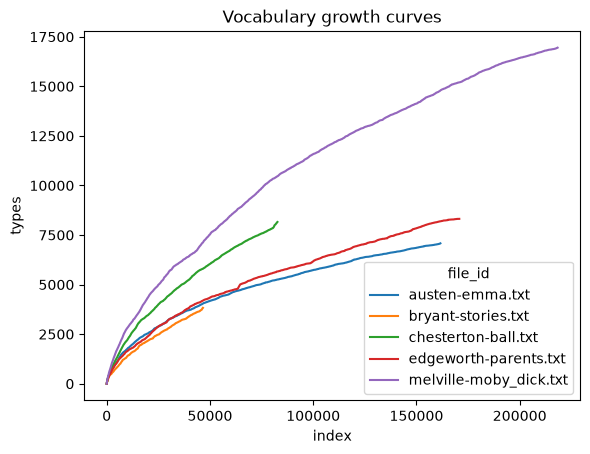

In [18]:
vgc = books.with_columns(
    plc.vocabulary_growth("token").alias("types").over("file_id"),
    pl.row_index().over("file_id").alias("index"),
)

sns.lineplot(vgc, x="index", y="types", hue="file_id")
plt.title("Vocabulary growth curves")

## The frequency spectrum

Underneath all of these measures is a single distribution: how many types occur once, how many twice, and so on. `frequency_spectrum` returns it as a struct with fields `m`, the frequency class, and `V(m,N)`, the number of types in that class. We use `unnest` to separate this into two columns.

`plc.proportion` divides each class by the total number of types and `cum_sum` accumulates them. Because the result is assigned back through `with_columns` without an alias, it replaces `V(m,N)` in place: the column keeps its name while the values become a cumulative share running to 1.

Text(0.5, 1.0, 'Cumulative frequency spectrum: Moby Dick')

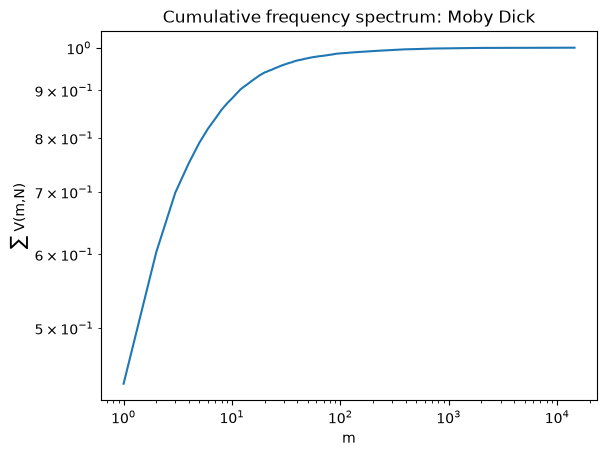

In [19]:
mb_spectrum = (
    books.filter(pl.col("file_id") == "melville-moby_dick.txt")
    .select(plc.frequency_spectrum("token", sort=True))
    .unnest()
    .with_columns(plc.proportion(pl.col("V(m,N)")).cum_sum())
)

sns.lineplot(mb_spectrum, x="m", y="V(m,N)")
plt.loglog()
plt.ylabel(r"$\sum$ V(m,N)")
plt.title("Cumulative frequency spectrum: Moby Dick")

The curve starts just under 0.45, so something over four types in ten in *Moby-Dick* occur exactly once. It is past 0.9 well before $m = 100$, and the flat stretch running out beyond $m = 10^4$ is the handful of function words that carry most of the tokens. Both axes are logarithmic because the frequency classes span four orders of magnitude while nearly all the types sit in the first few.

Overlaying the spectrum of a second book, `austen-emma.txt`, puts the two shapes together. *Moby-Dick* starts higher and stays above it through the low classes -- a larger share of its vocabulary appears once or twice -- and the two converge only in the tail.

Text(0.5, 1.0, 'Cumulative frequency spectrum')

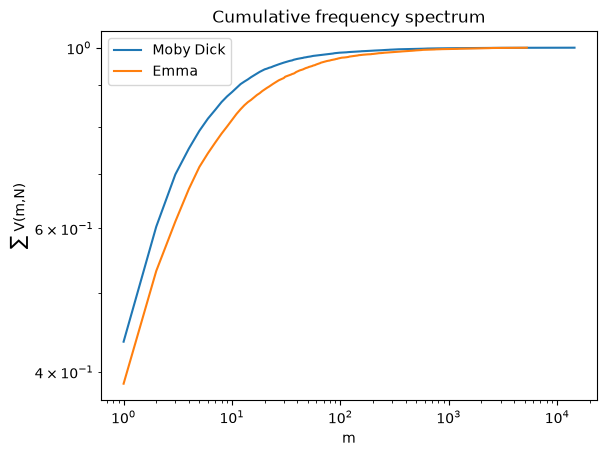

In [22]:
e_spectrum = (
    books.filter(pl.col("file_id") == "austen-emma.txt")
    .select(plc.frequency_spectrum("token", sort=True))
    .unnest()
    .with_columns(plc.proportion(pl.col("V(m,N)")).cum_sum())
)

sns.lineplot(mb_spectrum, x="m", y="V(m,N)", label="Moby Dick")
sns.lineplot(e_spectrum, x="m", y="V(m,N)", label="Emma")
plt.ylabel(r"$\sum$ V(m,N)")
plt.loglog()
plt.title("Cumulative frequency spectrum")